# Stage 0: Data Exploration

This notebook explores the two input datasets for the Health Claims Fact-Checker project:

1. **Test Claims** (`data/test_claims.json`) — 133 health claims with ground-truth verdicts
2. **PubMed Corpus** (`data/corpus.json`) — 224 PubMed abstracts used as the retrieval knowledge base

We examine: verdict distribution, category coverage, difficulty balance, corpus topic coverage, and corpus-claim alignment.

In [23]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Find project root (directory containing pyproject.toml)
_nb_dir = Path(os.path.abspath("")).resolve()
_project_root = _nb_dir
while _project_root != _project_root.parent:
    if (_project_root / "pyproject.toml").exists():
        break
    _project_root = _project_root.parent
os.chdir(_project_root)
print(f"Working directory: {os.getcwd()}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

with open("data/test_claims.json") as f:
    claims = json.load(f)

with open("data/corpus.json") as f:
    corpus = json.load(f)

print(f"Test claims: {len(claims)}")
print(f"Corpus articles: {len(corpus)}")

Working directory: /Users/ikhyvicky/Documents/MITB_stuff/CS614 -Gen AI/CS614-Group-Project
Test claims: 182
Corpus articles: 224


## 0.1 Test Claims — Verdict Distribution

Our 4-class verdict taxonomy:
- **SUPPORTED**: Claim is backed by strong scientific evidence
- **UNSUPPORTED**: Claim contradicts the scientific consensus
- **OVERSTATED**: Claim has a kernel of truth but exaggerates/oversimplifies
- **INSUFFICIENT_EVIDENCE**: Not enough research to confirm or deny

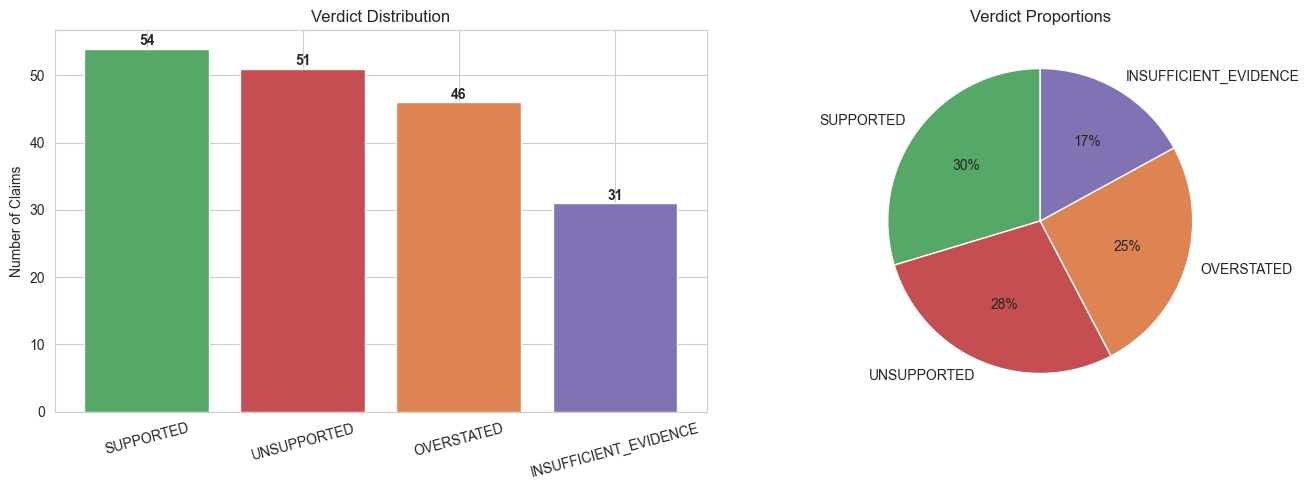


Verdict counts:
  SUPPORTED: 54
  UNSUPPORTED: 51
  OVERSTATED: 46
  INSUFFICIENT_EVIDENCE: 31


In [24]:
verdict_counts = Counter(c["expected_verdict"] for c in claims)
verdict_order = ["SUPPORTED", "UNSUPPORTED", "OVERSTATED", "INSUFFICIENT_EVIDENCE"]
colors_verdict = ["#55A868", "#C44E52", "#DD8452", "#8172B3"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = [verdict_counts.get(v, 0) for v in verdict_order]
bars = ax1.bar(verdict_order, counts, color=colors_verdict)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(count), ha="center", fontweight="bold")
ax1.set_ylabel("Number of Claims")
ax1.set_title("Verdict Distribution")
ax1.tick_params(axis="x", rotation=15)

# Pie chart
ax2.pie(counts, labels=verdict_order, colors=colors_verdict, autopct="%1.0f%%",
        startangle=90, textprops={"fontsize": 10})
ax2.set_title("Verdict Proportions")

plt.tight_layout()
plt.show()

print(f"\nVerdict counts:")
for v in verdict_order:
    print(f"  {v}: {verdict_counts.get(v, 0)}")

## 0.2 Claims by Health Category

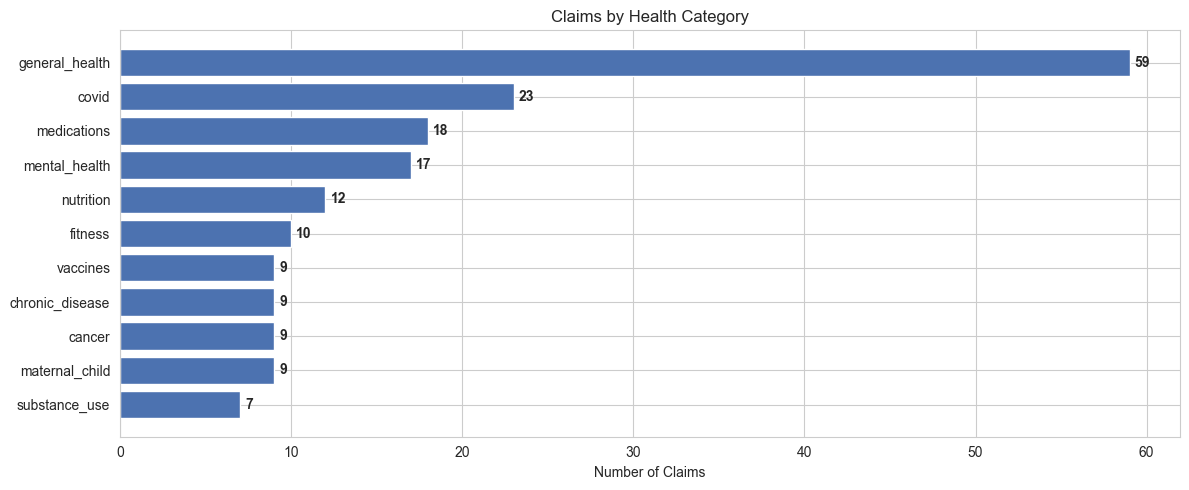


11 categories total


In [25]:
cat_counts = Counter(c.get("category", "unknown") for c in claims)
cat_sorted = sorted(cat_counts.items(), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(12, 5))
categories = [c[0] for c in cat_sorted]
cat_values = [c[1] for c in cat_sorted]
bars = ax.barh(categories[::-1], cat_values[::-1], color="#4C72B0")
for bar, val in zip(bars, cat_values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontweight="bold")
ax.set_xlabel("Number of Claims")
ax.set_title("Claims by Health Category")
plt.tight_layout()
plt.show()

print(f"\n{len(cat_counts)} categories total")

## 0.3 Verdict × Category Heatmap

Which categories have which verdict types?

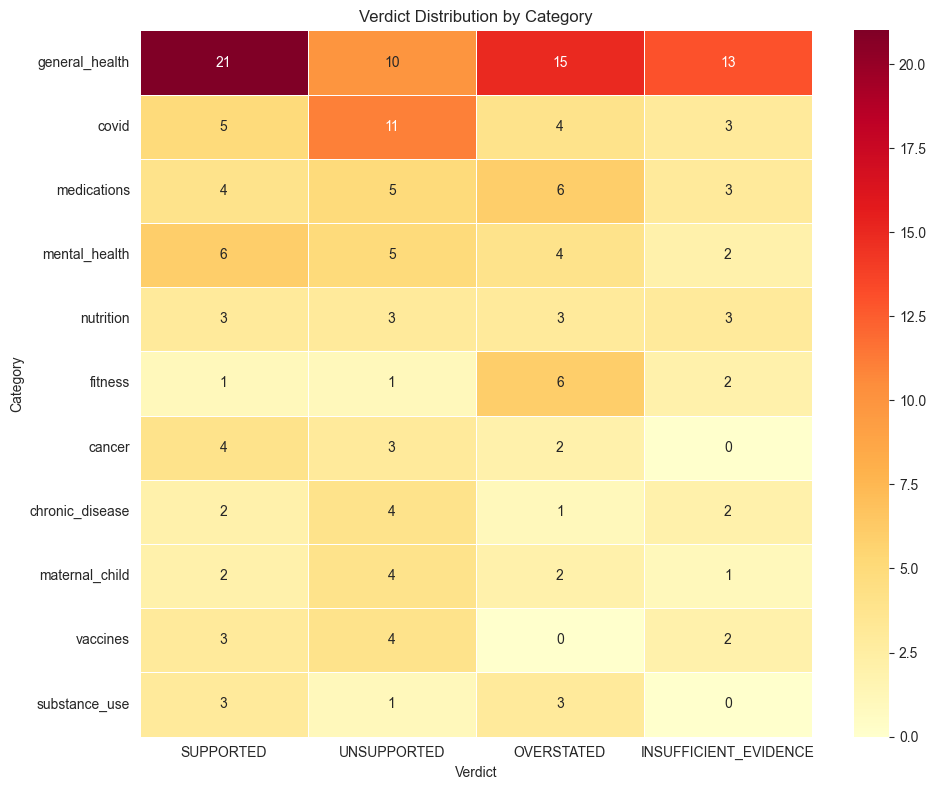

In [26]:
df_claims = pd.DataFrame(claims)
cross = pd.crosstab(df_claims["category"], df_claims["expected_verdict"])
cross = cross.reindex(columns=verdict_order, fill_value=0)
cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Verdict Distribution by Category")
ax.set_ylabel("Category")
ax.set_xlabel("Verdict")
plt.tight_layout()
plt.show()

## 0.4 Difficulty Distribution

Claims are tagged as `easy`, `medium`, `hard`, or `nuanced` based on how straightforward the scientific consensus is.

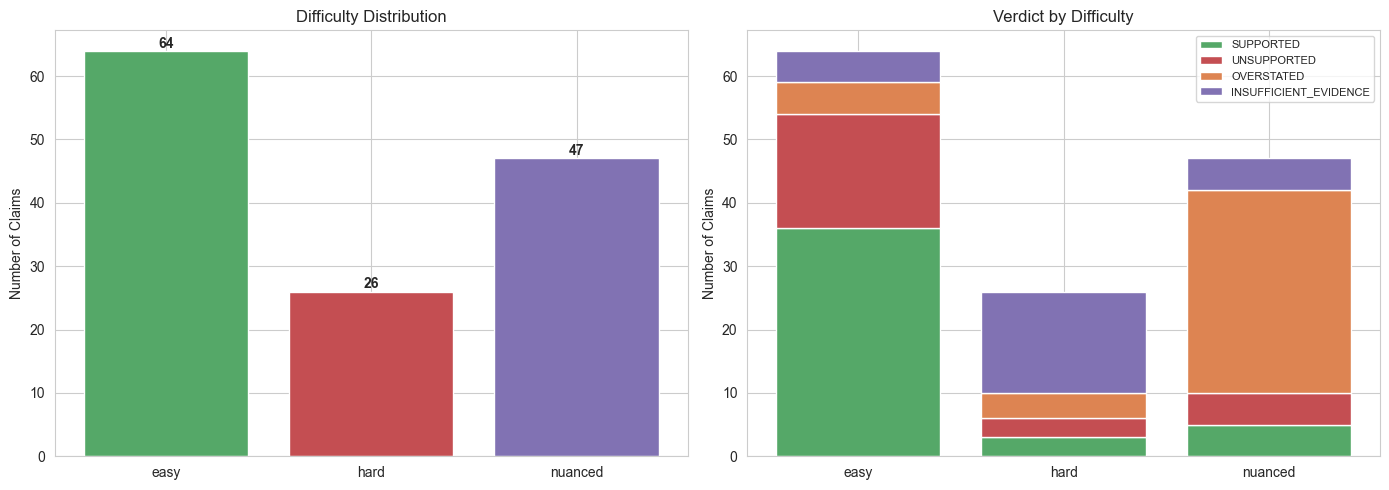

In [27]:
diff_counts = Counter(c.get("difficulty", "unknown") for c in claims)
diff_order = ["easy", "medium", "hard", "nuanced", "unknown"]
diff_order = [d for d in diff_order if d in diff_counts]
diff_colors = {"easy": "#55A868", "medium": "#DD8452", "hard": "#C44E52", "nuanced": "#8172B3", "unknown": "#999999"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Difficulty bar
d_vals = [diff_counts[d] for d in diff_order]
ax1.bar(diff_order, d_vals, color=[diff_colors[d] for d in diff_order])
for i, v in enumerate(d_vals):
    ax1.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
ax1.set_ylabel("Number of Claims")
ax1.set_title("Difficulty Distribution")

# Difficulty × Verdict stacked bar
diff_verdict = {}
for c in claims:
    d = c.get("difficulty", "unknown")
    v = c["expected_verdict"]
    diff_verdict.setdefault(d, Counter())[v] += 1

bottoms = {d: 0 for d in diff_order}
for vi, verdict in enumerate(verdict_order):
    vals = [diff_verdict.get(d, Counter()).get(verdict, 0) for d in diff_order]
    ax2.bar(diff_order, vals, bottom=[bottoms[d] for d in diff_order],
            color=colors_verdict[vi], label=verdict)
    for d, val in zip(diff_order, vals):
        bottoms[d] += val

ax2.set_ylabel("Number of Claims")
ax2.set_title("Verdict by Difficulty")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 0.5 Sample Claims by Verdict

A few example claims from each verdict category.

In [28]:
for verdict in verdict_order:
    subset = [c for c in claims if c["expected_verdict"] == verdict]
    print(f"\n{'='*70}")
    print(f"{verdict} ({len(subset)} claims) — examples:")
    print(f"{'='*70}")
    for c in subset[:3]:
        diff = c.get("difficulty", "?")
        cat = c.get("category", "?")
        print(f"  [{diff:>8}] [{cat:>15}] {c['claim']}")


SUPPORTED (54 claims) — examples:
  [    easy] [       vaccines] Flu vaccines reduce hospitalisation in elderly patients
  [moderate] [ general_health] This Blood Test Could Help Predict If A Pregnancy Is At Risk For Premature Labor
  [moderate] [ general_health] Alissa Keny-Guyer Says "in Oregon only 41 percent of adults have ever been tested" for HIV.

UNSUPPORTED (51 claims) — examples:
  [    easy] [       vaccines] Vaccines cause autism
  [    easy] [       vaccines] The MMR vaccine is linked to autism in children
  [    easy] [       vaccines] mRNA vaccines alter your DNA

OVERSTATED (46 claims) — examples:
  [ nuanced] [          covid] Vitamin D supplements prevent COVID infection
  [ nuanced] [chronic_disease] Intermittent fasting reverses Type 2 diabetes
  [    hard] [          covid] COVID vaccines are effective against all variants

INSUFFICIENT_EVIDENCE (31 claims) — examples:
  [    hard] [          covid] If someone with the new coronavirus sneezes, it travels about 10 

## 0.6 Claim Length Distribution

Are some verdict types associated with longer or shorter claim text?

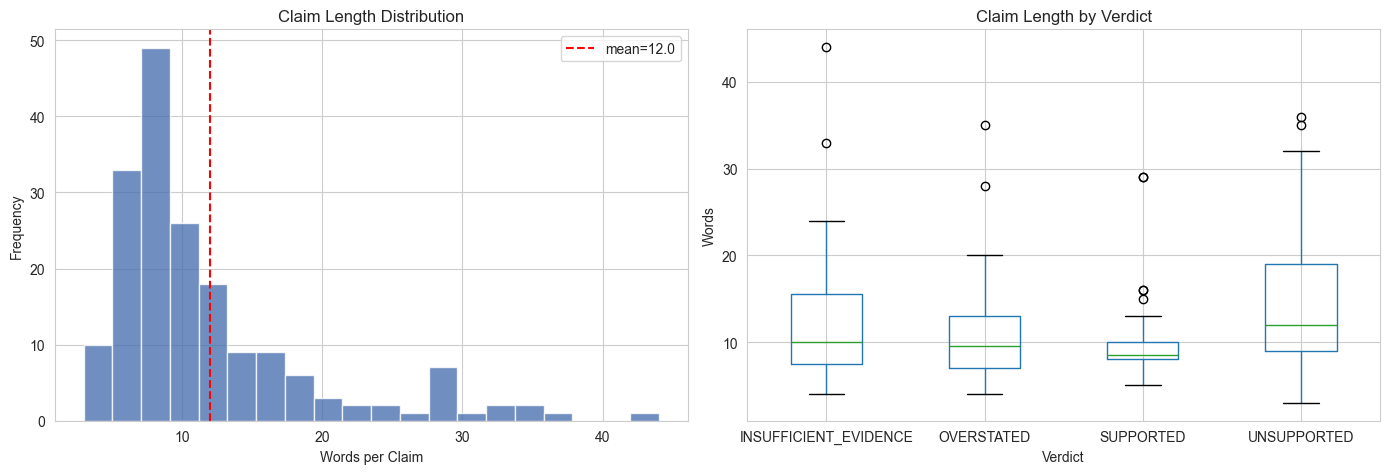

Claim length stats:
  Min: 3 words
  Max: 44 words
  Mean: 12.0 words
  Median: 9 words


In [29]:
df_claims["claim_words"] = df_claims["claim"].apply(lambda x: len(x.split()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(df_claims["claim_words"], bins=20, color="#4C72B0", edgecolor="white", alpha=0.8)
ax1.axvline(df_claims["claim_words"].mean(), color="red", linestyle="--",
            label=f"mean={df_claims['claim_words'].mean():.1f}")
ax1.set_xlabel("Words per Claim")
ax1.set_ylabel("Frequency")
ax1.set_title("Claim Length Distribution")
ax1.legend()

# Box plot by verdict
df_claims.boxplot(column="claim_words", by="expected_verdict", ax=ax2)
ax2.set_title("Claim Length by Verdict")
ax2.set_xlabel("Verdict")
ax2.set_ylabel("Words")
plt.suptitle("")  # Remove auto-title

plt.tight_layout()
plt.show()

print(f"Claim length stats:")
print(f"  Min: {df_claims['claim_words'].min()} words")
print(f"  Max: {df_claims['claim_words'].max()} words")
print(f"  Mean: {df_claims['claim_words'].mean():.1f} words")
print(f"  Median: {df_claims['claim_words'].median():.0f} words")

## 0.7 Data Source

All 133 claims are sourced from the PUBHEALTH dataset with consistent labeling.

In [30]:
source_counts = Counter(c.get("source", "unknown") for c in claims)
print("Claim sources:")
for src, count in source_counts.most_common():
    print(f"  {src}: {count}")

# Show a few sample claims
print(f"\nSample claims:")
for c in claims[:10]:
    print(f"  [{c['expected_verdict']:>24}] [{c.get('category','?'):>15}] {c['claim'][:70]}")

Claim sources:
  PUBHEALTH: 182

Sample claims:
  [             UNSUPPORTED] [       vaccines] Vaccines cause autism
  [             UNSUPPORTED] [       vaccines] The MMR vaccine is linked to autism in children
  [              OVERSTATED] [          covid] Vitamin D supplements prevent COVID infection
  [              OVERSTATED] [chronic_disease] Intermittent fasting reverses Type 2 diabetes
  [             UNSUPPORTED] [       vaccines] mRNA vaccines alter your DNA
  [              OVERSTATED] [          covid] COVID vaccines are effective against all variants
  [               SUPPORTED] [       vaccines] Flu vaccines reduce hospitalisation in elderly patients
  [               SUPPORTED] [ general_health] This Blood Test Could Help Predict If A Pregnancy Is At Risk For Prema
  [               SUPPORTED] [ general_health] Alissa Keny-Guyer Says "in Oregon only 41 percent of adults have ever 
  [               SUPPORTED] [  mental_health] Rhode Island law aims to prevent suicides a

---

## 0.8 PubMed Corpus Overview

The retrieval corpus consists of 224 PubMed abstracts fetched across 46 search queries covering all claim categories.

In [31]:
df_corpus = pd.DataFrame(corpus)

print(f"Corpus size: {len(df_corpus)} articles")
print(f"Articles with abstracts: {df_corpus['abstract'].notna().sum()}")

# Abstract length stats
df_corpus["abstract_words"] = df_corpus["abstract"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
print(f"\nAbstract length:")
print(f"  Min: {df_corpus['abstract_words'].min()} words")
print(f"  Max: {df_corpus['abstract_words'].max()} words")
print(f"  Mean: {df_corpus['abstract_words'].mean():.0f} words")
print(f"  Total words: {df_corpus['abstract_words'].sum():,}")

# Year distribution
df_corpus["year"] = pd.to_numeric(df_corpus["year"], errors="coerce")
print(f"\nPublication years: {int(df_corpus['year'].min())} — {int(df_corpus['year'].max())}")

Corpus size: 224 articles
Articles with abstracts: 224

Abstract length:
  Min: 29 words
  Max: 1136 words
  Mean: 245 words
  Total words: 54,896

Publication years: 1995 — 2025


## 0.9 Corpus — Publication Year Distribution

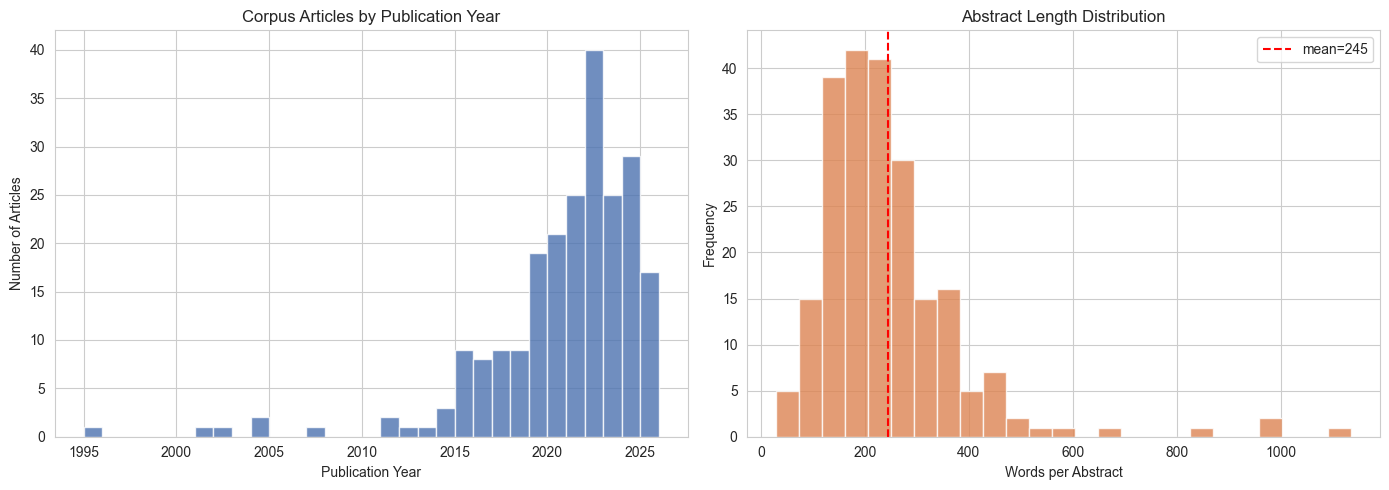

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Year histogram
year_data = df_corpus["year"].dropna().astype(int)
ax1.hist(year_data, bins=range(year_data.min(), year_data.max() + 2), color="#4C72B0", edgecolor="white", alpha=0.8)
ax1.set_xlabel("Publication Year")
ax1.set_ylabel("Number of Articles")
ax1.set_title("Corpus Articles by Publication Year")

# Abstract length histogram
ax2.hist(df_corpus["abstract_words"], bins=25, color="#DD8452", edgecolor="white", alpha=0.8)
ax2.axvline(df_corpus["abstract_words"].mean(), color="red", linestyle="--",
            label=f"mean={df_corpus['abstract_words'].mean():.0f}")
ax2.set_xlabel("Words per Abstract")
ax2.set_ylabel("Frequency")
ax2.set_title("Abstract Length Distribution")
ax2.legend()

plt.tight_layout()
plt.show()

## 0.10 Corpus — Topic Coverage by Search Query

Each article was fetched using a specific PubMed search query. This shows how evenly the corpus covers different health topics.

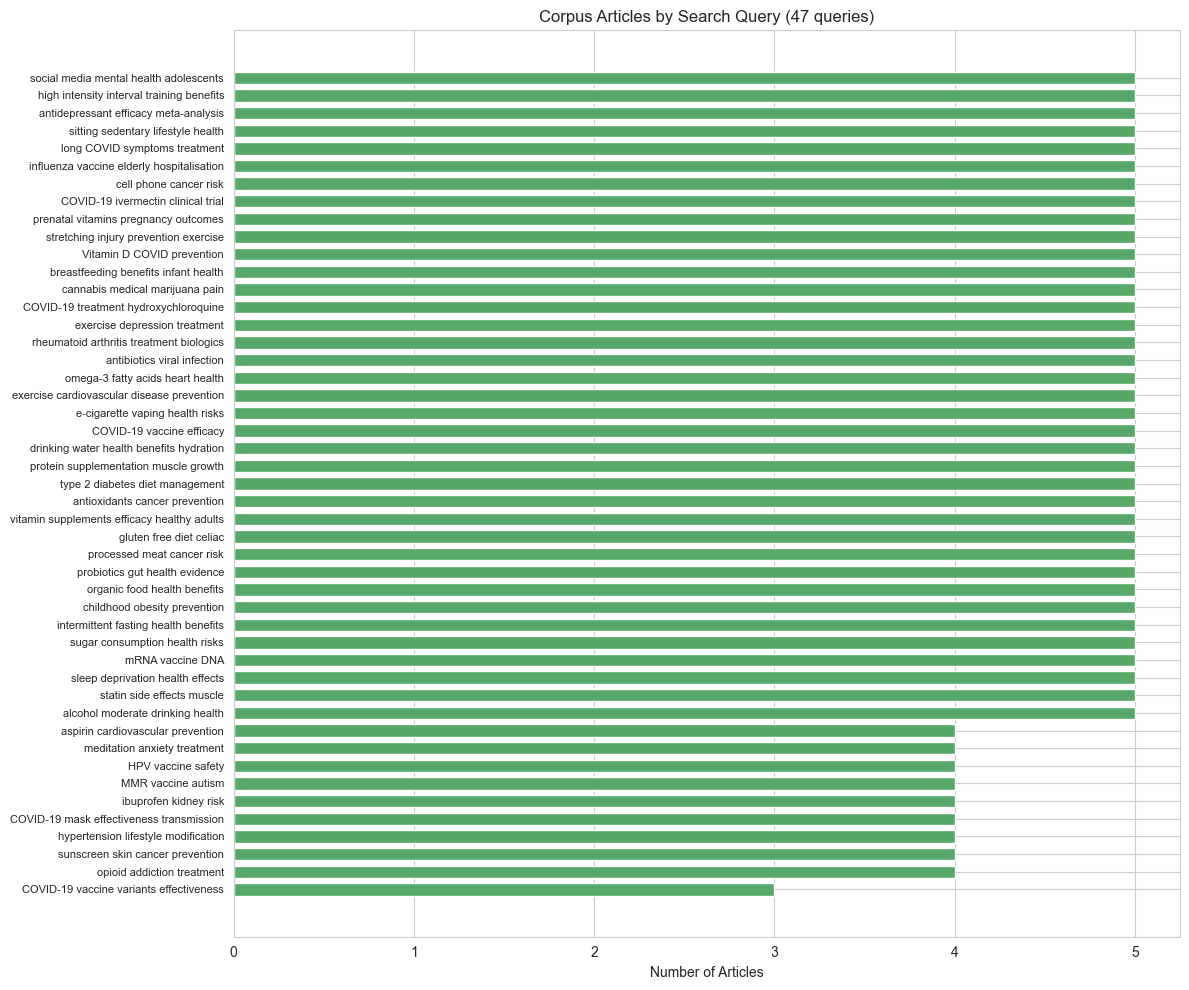


Articles per query: min=3, max=5, mean=4.8


In [33]:
query_counts = Counter(a.get("query", "unknown") for a in corpus)
query_sorted = sorted(query_counts.items(), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(12, 10))
queries = [q[0][:45] for q in query_sorted]
qvals = [q[1] for q in query_sorted]
bars = ax.barh(queries[::-1], qvals[::-1], color="#55A868", height=0.7)
ax.set_xlabel("Number of Articles")
ax.set_title(f"Corpus Articles by Search Query ({len(query_counts)} queries)")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

print(f"\nArticles per query: min={min(qvals)}, max={max(qvals)}, mean={sum(qvals)/len(qvals):.1f}")

## 0.11 Corpus — Sample Articles

A few example articles from the corpus showing titles and abstract snippets.

In [34]:
import random
random.seed(42)
samples = random.sample(corpus, min(8, len(corpus)))

for i, art in enumerate(samples, 1):
    print(f"{i}. [{art['pmid']}] {art['title'][:80]}")
    print(f"   Year: {art.get('year', 'N/A')}  |  Query: {art.get('query', 'N/A')}")
    print(f"   Abstract: {art['abstract'][:150]}...")
    print()

1. [39863946] Role of ivermectin and colchicine in the treatment of COVID-19: a randomized con
   Year: 2024  |  Query: COVID-19 ivermectin clinical trial
   Abstract: INTRODUCTION: The objective of this study was to assess the effectiveness of ivermectin and colchicine as treatment options for coronavirus disease 20...

2. [36075680] Exercise for Primary and Secondary Prevention of Cardiovascular Disease: JACC Fo
   Year: 2022  |  Query: exercise cardiovascular disease prevention
   Abstract: Regular exercise that meets or exceeds the current physical activity guidelines is associated with a reduced risk of cardiovascular disease (CVD) and ...

3. [33275134] Effect of High-Dose Trivalent vs Standard-Dose Quadrivalent Influenza Vaccine on
   Year: 2021  |  Query: influenza vaccine elderly hospitalisation
   Abstract: IMPORTANCE: Influenza is temporally associated with cardiopulmonary morbidity and mortality among those with cardiovascular disease who may mount a le...

4. [41321218] As

## 0.12 Corpus–Claim Alignment Check

For each claim category, how many corpus articles were fetched with related queries? This helps identify potential coverage gaps where the retrieval system may struggle.

In [35]:
# Map claim categories to related corpus query keywords
category_keywords = {
    "vaccines": ["vaccine", "mmr", "hpv", "influenza", "mrna"],
    "covid": ["covid", "coronavirus", "sars-cov", "hydroxychloroquine", "ivermectin", "mask", "vitamin d covid"],
    "general_health": ["sleep", "exercise", "water", "hydration", "organic food", "sugar", "sitting", "sedentary"],
    "mental_health": ["mental health", "depression", "anxiety", "meditation", "antidepressant", "social media"],
    "medications": ["aspirin", "statin", "antibiotic", "opioid", "ibuprofen", "nsaid"],
    "cancer": ["cancer", "cell phone", "sunscreen", "antioxidant", "processed meat"],
    "nutrition": ["vitamin supplement", "gluten", "omega-3", "probiotic"],
    "maternal_child": ["breastfeeding", "prenatal", "pregnancy", "childhood obesity", "infant"],
    "fitness": ["interval training", "stretching", "protein supplement", "hiit"],
    "chronic_disease": ["diabetes", "hypertension", "rheumatoid arthritis"],
    "substance_use": ["e-cigarette", "vaping", "alcohol", "cannabis", "marijuana"],
}

print(f"{'Category':<20} {'Claims':>7} {'Corpus Articles':>16} {'Coverage Ratio':>15}")
print("-" * 62)

for cat in [c[0] for c in cat_sorted]:
    n_claims = cat_counts[cat]
    keywords = category_keywords.get(cat, [])
    
    # Count corpus articles matching any keyword
    matching = 0
    for art in corpus:
        text = (art.get("title", "") + " " + art.get("query", "")).lower()
        if any(kw in text for kw in keywords):
            matching += 1
    
    ratio = matching / n_claims if n_claims > 0 else 0
    bar = "#" * min(int(ratio * 5), 20)
    print(f"{cat:<20} {n_claims:>7} {matching:>16} {ratio:>14.1f}x  {bar}")

Category              Claims  Corpus Articles  Coverage Ratio
--------------------------------------------------------------
general_health            59               43            0.7x  ###
covid                     23               33            1.4x  #######
medications               18               22            1.2x  ######
mental_health             17               19            1.1x  #####
nutrition                 12               21            1.8x  ########
fitness                   10               15            1.5x  #######
vaccines                   9               26            2.9x  ##############
chronic_disease            9               16            1.8x  ########
cancer                     9               22            2.4x  ############
maternal_child             9               15            1.7x  ########
substance_use              7               15            2.1x  ##########


## 0.13 Summary Statistics

In [36]:
summary = pd.DataFrame([
    {"Dataset": "Test Claims", "Size": len(claims), "Detail": f"{len(verdict_counts)} verdicts, {len(cat_counts)} categories"},
    {"Dataset": "PubMed Corpus", "Size": len(corpus), "Detail": f"{len(query_counts)} search queries, {df_corpus['abstract_words'].sum():,} total words"},
])
print(summary.to_string(index=False))

print(f"\n--- Test Claims ---")
print(f"  Total: {len(claims)}")
print(f"  Verdicts: {dict(verdict_counts)}")
print(f"  Categories: {len(cat_counts)}")
print(f"  Sources: {dict(source_counts)}")
print(f"  Avg claim length: {df_claims['claim_words'].mean():.1f} words")

print(f"\n--- PubMed Corpus ---")
print(f"  Total articles: {len(corpus)}")
print(f"  Search queries: {len(query_counts)}")
print(f"  Year range: {int(df_corpus['year'].min())} — {int(df_corpus['year'].max())}")
print(f"  Avg abstract length: {df_corpus['abstract_words'].mean():.0f} words")
print(f"  Total corpus words: {df_corpus['abstract_words'].sum():,}")

      Dataset  Size                                Detail
  Test Claims   182             4 verdicts, 11 categories
PubMed Corpus   224 47 search queries, 54,896 total words

--- Test Claims ---
  Total: 182
  Verdicts: {'UNSUPPORTED': 51, 'OVERSTATED': 46, 'SUPPORTED': 54, 'INSUFFICIENT_EVIDENCE': 31}
  Categories: 11
  Sources: {'PUBHEALTH': 182}
  Avg claim length: 12.0 words

--- PubMed Corpus ---
  Total articles: 224
  Search queries: 47
  Year range: 1995 — 2025
  Avg abstract length: 245 words
  Total corpus words: 54,896


## Key Takeaways

| Metric | Value |
|--------|-------|
| Test claims | 133 from PUBHEALTH |
| Verdict classes | 4 (SUPPORTED, UNSUPPORTED, OVERSTATED, INSUFFICIENT_EVIDENCE) |
| Health categories | 11 |
| Difficulty levels | 4 (easy, moderate, hard, nuanced) |
| Corpus articles | 224 PubMed abstracts |
| Search queries | 47 covering all claim categories |
| Corpus year range | 1995 — 2025 |

**Class balance:** SUPPORTED and UNSUPPORTED are well-represented (~41-43 each). OVERSTATED has ~33. INSUFFICIENT_EVIDENCE is the smallest class (~16) — this reflects real-world scarcity of "not enough evidence" claims.

**Coverage:** Every claim category has related corpus articles. Categories like vaccines and covid have the highest corpus coverage ratio, while general_health claims (the largest category) rely on diverse, spread-out evidence.

**Next step:** Stage 1 (Chunking Strategies) processes this corpus into retrievable chunks.